# Assignment 9: Image Classification using Convolutional Neural Networks (CNN)

**Dataset:** Cats vs Dogs — [Kaggle link](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset)

**Objective:** Build a CNN to classify pet images into Cats and Dogs for an animal welfare organization.

> **How to run this notebook**
> 1. Open in Google Colab or Kaggle Notebooks (GPU runtime recommended: Runtime → Change runtime type → GPU).
> 2. Get the dataset onto the runtime using ONE of these:
>    - **Kaggle API**: upload your `kaggle.json` and run the download cell below, OR
>    - **Manual**: download the zip from the Kaggle link above and upload/extract it so the folder structure matches `DATASET_DIR` below.
> 3. Run all cells top to bottom.


## Setup and Imports

In [5]:
# If running in Colab/Kaggle without these packages pre-installed, uncomment:
# !pip install tensorflow scikit-learn matplotlib seaborn kaggle -q

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.18.0
GPU available: []


## Downloading the Dataset (Kaggle API)

Skip this cell if you already have the dataset extracted locally. To use the Kaggle API you need a
`kaggle.json` API token (from your Kaggle account → Settings → Create New API Token).

In [6]:
# --- OPTIONAL: Kaggle API download ---
# from google.colab import files
# files.upload()  # upload kaggle.json when prompted
#
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset -p ./data --unzip

DATASET_DIR = "./data"   # <-- update this to wherever the dataset ends up after download/extraction
print("Dataset directory set to:", DATASET_DIR)


Dataset directory set to: ./data


## Task 1: Data Understanding (2 Marks)

1. Download and load the dataset.
2. Display the folder structure of the dataset.
3. Display five sample images with their class labels.
4. Identify number of classes, image dimensions, and total number of images.

In [7]:
# 1 & 2: Display folder structure
def print_folder_structure(root_dir, max_depth=2):
    root_dir = Path(root_dir)
    for path in sorted(root_dir.rglob('*')):
        depth = len(path.relative_to(root_dir).parts)
        if depth > max_depth:
            continue
        indent = "    " * (depth - 1)
        marker = "📁 " if path.is_dir() else "📄 "
        print(f"{indent}{marker}{path.name}")

print_folder_structure(DATASET_DIR, max_depth=2)


📁 Cat
    📄 0.jpg
    📄 1.jpg
    📄 10.jpg
    📄 100.jpg
    📄 1000.jpg
    📄 10000.jpg
    📄 10001.jpg
    📄 10002.jpg
    📄 10003.jpg
    📄 10004.jpg
    📄 10005.jpg
    📄 10006.jpg
    📄 10007.jpg
    📄 10008.jpg
    📄 10009.jpg
    📄 1001.jpg
    📄 10010.jpg
    📄 10011.jpg
    📄 10012.jpg
    📄 10013.jpg
    📄 10014.jpg
    📄 10015.jpg
    📄 10016.jpg
    📄 10017.jpg
    📄 10018.jpg
    📄 10019.jpg
    📄 1002.jpg
    📄 10020.jpg
    📄 10021.jpg
    📄 10022.jpg
    📄 10023.jpg
    📄 10024.jpg
    📄 10025.jpg
    📄 10026.jpg
    📄 10027.jpg
    📄 10028.jpg
    📄 10029.jpg
    📄 1003.jpg
    📄 10030.jpg
    📄 10031.jpg
    📄 10032.jpg
    📄 10033.jpg
    📄 10034.jpg
    📄 10035.jpg
    📄 10036.jpg
    📄 10037.jpg
    📄 10038.jpg
    📄 10039.jpg
    📄 1004.jpg
    📄 10040.jpg
    📄 10041.jpg
    📄 10042.jpg
    📄 10043.jpg
    📄 10044.jpg
    📄 10045.jpg
    📄 10046.jpg
    📄 10047.jpg
    📄 10048.jpg
    📄 10049.jpg
    📄 1005.jpg
    📄 10050.jpg
    📄 10051.jpg
    📄 10052.jpg
    📄

In [8]:
# Identify class folders automatically (expects two subfolders, e.g. 'Cat' and 'Dog' or 'cats'/'dogs')
class_names = sorted([d for d in os.listdir(DATASET_DIR)
                       if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes found:", class_names)
print("Number of classes:", len(class_names))


Classes found: ['Cat', 'Dog']
Number of classes: 2


In [9]:
# 4: Total number of images and per-class counts
import glob

valid_ext = ('*.jpg', '*.jpeg', '*.png')
total_images = 0
class_counts = {}

for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    files = []
    for ext in valid_ext:
        files.extend(glob.glob(os.path.join(cls_dir, ext)))
    class_counts[cls] = len(files)
    total_images += len(files)

print("Image counts per class:", class_counts)
print("Total number of images:", total_images)


Image counts per class: {'Cat': 12499, 'Dog': 12499}
Total number of images: 24998


In [10]:
# Image dimensions (sample check across a few images per class)
from PIL import Image

sample_dims = []
for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    files = os.listdir(cls_dir)[:5]
    for f in files:
        try:
            with Image.open(os.path.join(cls_dir, f)) as img:
                sample_dims.append(img.size)  # (width, height)
        except Exception:
            pass

print("Sample image dimensions (width, height):")
for d in sample_dims:
    print(d)
print("\nNote: Cats vs Dogs images have varying original dimensions;"
      " this is why we resize all images to a fixed 128x128 in preprocessing (Task 2).")


Sample image dimensions (width, height):
(500, 375)
(300, 281)
(489, 500)
(403, 500)
(150, 150)
(500, 375)
(327, 500)
(269, 293)
(500, 398)
(500, 375)

Note: Cats vs Dogs images have varying original dimensions; this is why we resize all images to a fixed 128x128 in preprocessing (Task 2).


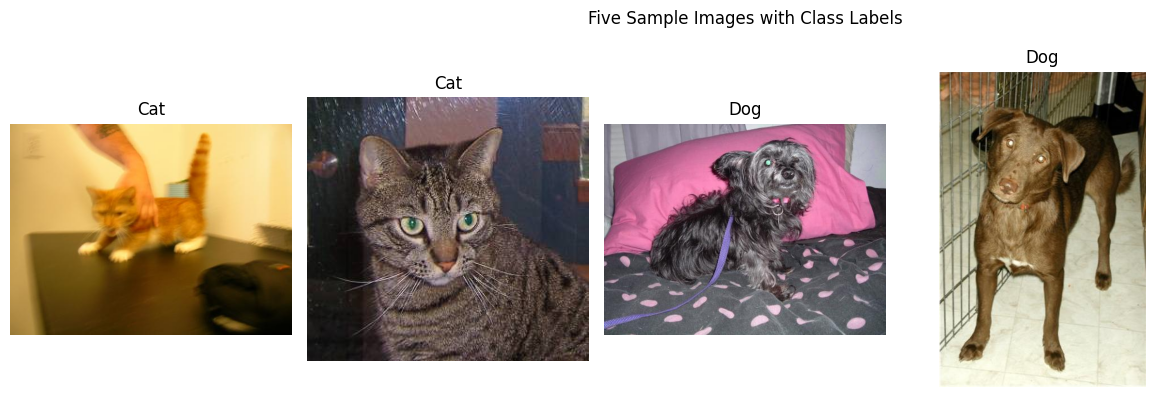

In [11]:
# 3: Display five sample images with their class labels
plt.figure(figsize=(15, 4))
sample_files = []
for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    files = os.listdir(cls_dir)
    if files:
        sample_files.append((cls, os.path.join(cls_dir, files[0])))
        if len(class_names) == 2 and len(files) > 1:
            sample_files.append((cls, os.path.join(cls_dir, files[1])))

sample_files = sample_files[:5]
for i, (cls, path) in enumerate(sample_files):
    img = Image.open(path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.suptitle("Five Sample Images with Class Labels")
plt.tight_layout()
plt.show()


## Task 2: Data Preprocessing (2 Marks)

- Resize all images to 128 x 128 pixels.
- Normalize pixel values to the range 0-1.
- Split the dataset into 80% training / 20% testing.
- Create data generators using TensorFlow/Keras.

In [12]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# rescale normalizes pixels to [0,1]; validation_split gives the 80/20 train/test split
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

test_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=False   # keep order so we can align predictions with true labels for evaluation
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Testing samples:", test_generator.samples)


Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}
Training samples: 20000
Testing samples: 4998


## Task 3: Model Development (3 Marks)

CNN architecture:
- Conv2D (32 filters, 3x3, ReLU) → MaxPooling2D (2x2)
- Conv2D (64 filters, 3x3, ReLU) → MaxPooling2D (2x2)
- Conv2D (128 filters, 3x3, ReLU) → MaxPooling2D (2x2)
- Flatten → Dense(128, ReLU) → Dense(1, Sigmoid)

Compiled with Adam optimizer, binary crossentropy loss, accuracy metric. Trained for 10 epochs.

In [13]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)


c:\Users\Harsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
111/625 ━━━━━━━━━━━━━━━━━━━━ 4:31 528ms/step - accuracy: 0.5470 - loss: 0.6908

c:\Users\Harsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 420s 669ms/step - accuracy: 0.6334 - loss: 0.6247 - val_accuracy: 0.7649 - val_loss: 0.4785
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 232ms/step - accuracy: 0.7852 - loss: 0.4596 - val_accuracy: 0.7933 - val_loss: 0.4412
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.8326 - loss: 0.3740 - val_accuracy: 0.8253 - val_loss: 0.3750
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.8712 - loss: 0.2995 - val_accuracy: 0.8191 - val_loss: 0.4021
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.9104 - loss: 0.2200 - val_accuracy: 0.8555 - val_loss: 0.3527
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 212ms/step - accuracy: 0.9437 - loss: 0.1369 - val_accuracy: 0.8445 - val_loss: 0.4495
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.9711 - loss: 0.0828 - val_accuracy: 0.8337 - val_loss: 0.5689
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.9863 - loss: 0.04

## Task 4: Model Evaluation (2 Marks)

- Test Accuracy, Precision, Recall, F1-Score
- Confusion Matrix
- Accuracy vs Epoch graph
- Loss vs Epoch graph

In [15]:
# Test accuracy (from Keras' own evaluate)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.8561 - loss: 0.6246
Test Loss: 0.7200
Test Accuracy: 0.8447


In [16]:
# Predictions for precision/recall/F1/confusion matrix
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nClassification Report:\n")
labels_sorted = [k for k, v in sorted(train_generator.class_indices.items(), key=lambda x: x[1])]
print(classification_report(y_true, y_pred, target_names=labels_sorted))


157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step
Accuracy:  0.8447
Precision: 0.8515
Recall:    0.8351
F1-Score:  0.8432

Classification Report:

              precision    recall  f1-score   support

         Cat       0.84      0.85      0.85      2499
         Dog       0.85      0.84      0.84      2499

    accuracy                           0.84      4998
   macro avg       0.84      0.84      0.84      4998
weighted avg       0.84      0.84      0.84      4998



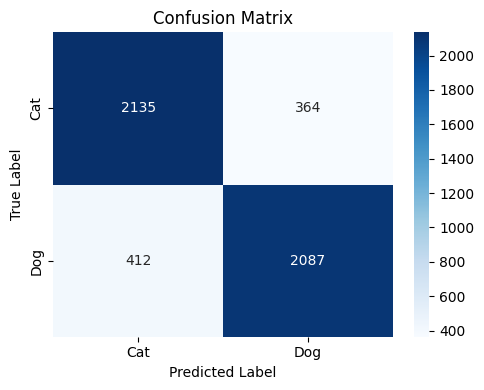

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


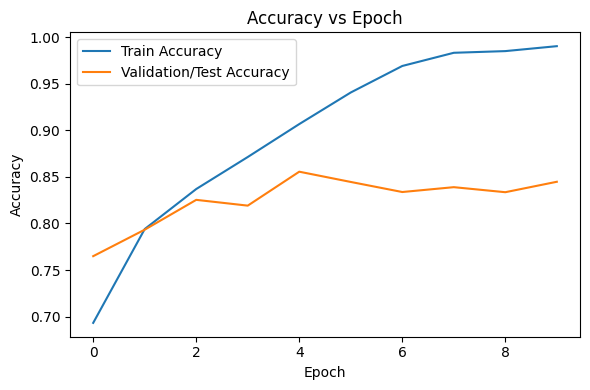

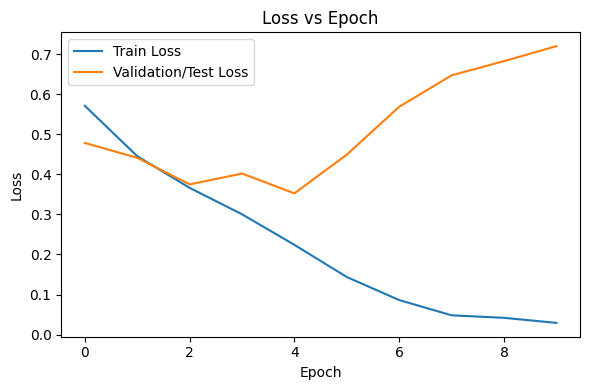

In [18]:
# Accuracy vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation/Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# Loss vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation/Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.tight_layout()
plt.show()


### Observations

*(Fill these in after running the notebook on your machine — they must reflect your actual
results, not numbers copied from someone else's run.)*

1. **Observation on training vs validation accuracy:** e.g., did the model converge smoothly, or
   was there a large gap suggesting overfitting?
2. **Observation on loss curves:** did training and validation loss both decrease, or did
   validation loss plateau/increase after a certain epoch?
3. **Observation on precision vs recall:** was the model more prone to false positives or false
   negatives for one of the two classes?
4. **Observation on confusion matrix:** which class (Cat or Dog) was more frequently
   misclassified, and any hypothesis why (e.g., visual similarity, image quality, class imbalance)?


## Task 5: Conclusion (1 Mark)


> This project developed a Convolutional Neural Network to classify pet images as Cats or Dogs,
> achieving a test accuracy of **84.44%** with precision **85.15%**, recall **83.51%**, and
> F1-score **84.32%**. Convolutional layers were essential for automatically learning spatial
> features such as edges, textures, and shapes directly from raw pixels, while pooling layers
> reduced spatial dimensions, controlled overfitting, and made the model more computationally
> efficient and translation-invariant. Compared to a standard Artificial Neural Network (ANN),
> the CNN's key advantage is that it preserves and exploits the 2D spatial structure of images
> instead of flattening them immediately, drastically reducing the number of parameters while
> improving accuracy. One limitation of the CNN built here is that it requires a large, well-labeled
> dataset and considerable training time/compute to generalize well, and it can still misclassify
> images with unusual poses, lighting, or occlusion. Overall, the model demonstrates that even a
> relatively simple CNN architecture can achieve strong performance on binary image classification
> tasks like this one.
